# Navier-Stokes Vorticity Legacy Notebook (Torch Migration)
Shared torch experiment wrapper for the 2D vorticity benchmark with both FFT-Poisson and kernel-Poisson streamfunction solves in separate cells.


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next((path for path in search_roots if (path / 'src' / 'krom').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from experiments import NS_Vorticity_clean


({'mean_final_rel_l2': 0.28171208363756856,
  'mean_energy_spectrum_rel_l2': 0.05452064694116406,
  'mean_krom_seconds': 23.640384937636554,
  'mean_full_order_seconds': 0.01497160418269535,
  'mean_streamfunction_rel_l2': 0.0,
  'mean_velocity_rel_l2': 0.0},
 {'mean_final_rel_l2': 0.283865922494392,
  'mean_energy_spectrum_rel_l2': 0.030111550935724356,
  'mean_krom_seconds': 24.386237097050373,
  'mean_full_order_seconds': 0.01573456955763201,
  'mean_streamfunction_rel_l2': 0.0,
  'mean_velocity_rel_l2': 0.0})

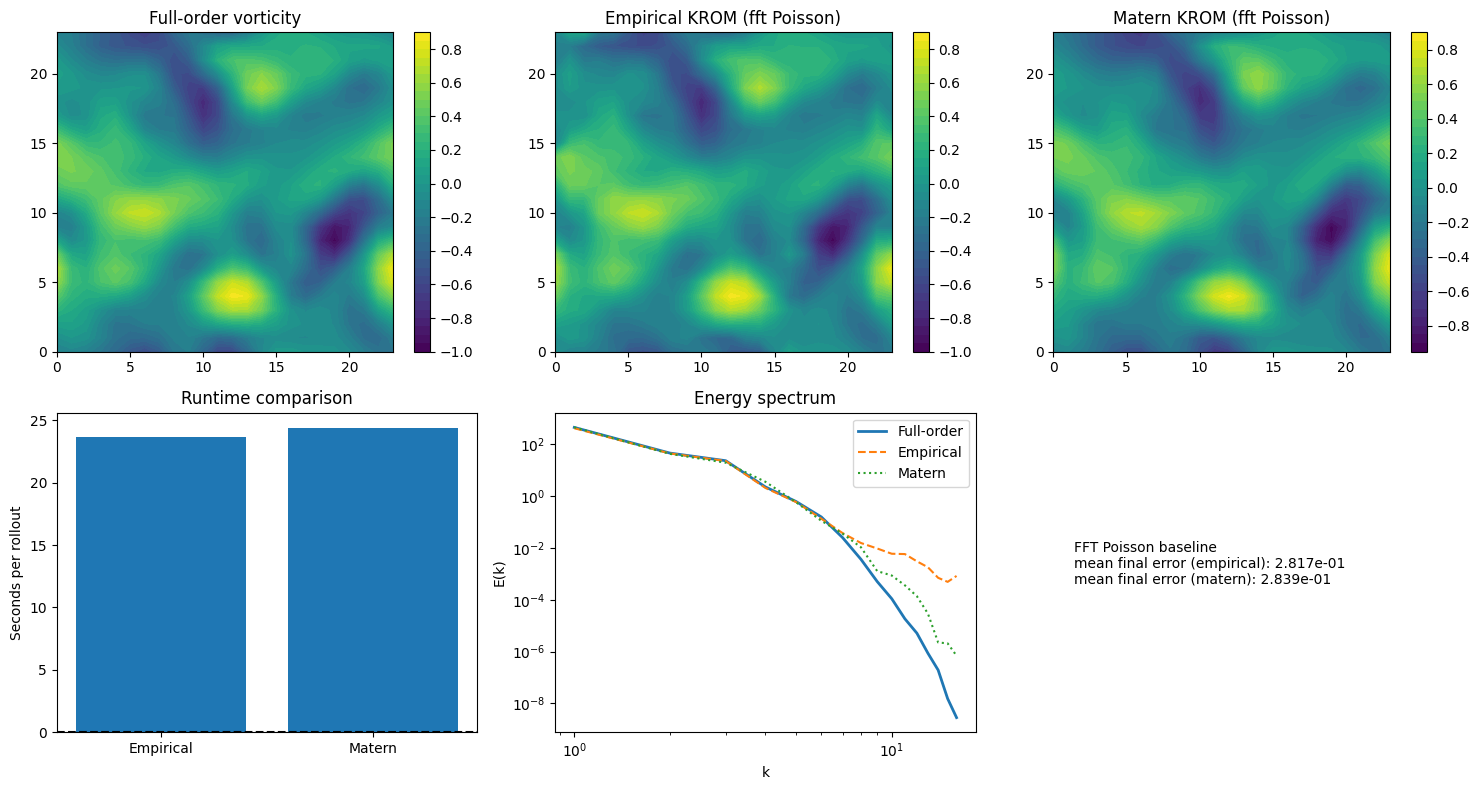

In [2]:
fft_result = NS_Vorticity_clean.run_experiment(poisson_solver='fft')
NS_Vorticity_clean.plot_experiment(fft_result)
fft_result['empirical'], fft_result['matern']


({'mean_final_rel_l2': 0.3311262449310965,
  'mean_energy_spectrum_rel_l2': 0.10597403341766282,
  'mean_krom_seconds': 36.43496167341558,
  'mean_full_order_seconds': 0.015201472289239367,
  'mean_streamfunction_rel_l2': 0.508058873710577,
  'mean_velocity_rel_l2': 0.6256398776795145},
 {'mean_final_rel_l2': 0.3468431960940052,
  'mean_energy_spectrum_rel_l2': 0.01850093924180115,
  'mean_krom_seconds': 36.0503102845978,
  'mean_full_order_seconds': 0.015371694617594281,
  'mean_streamfunction_rel_l2': 1.062445052998807,
  'mean_velocity_rel_l2': 1.1712328219718768})

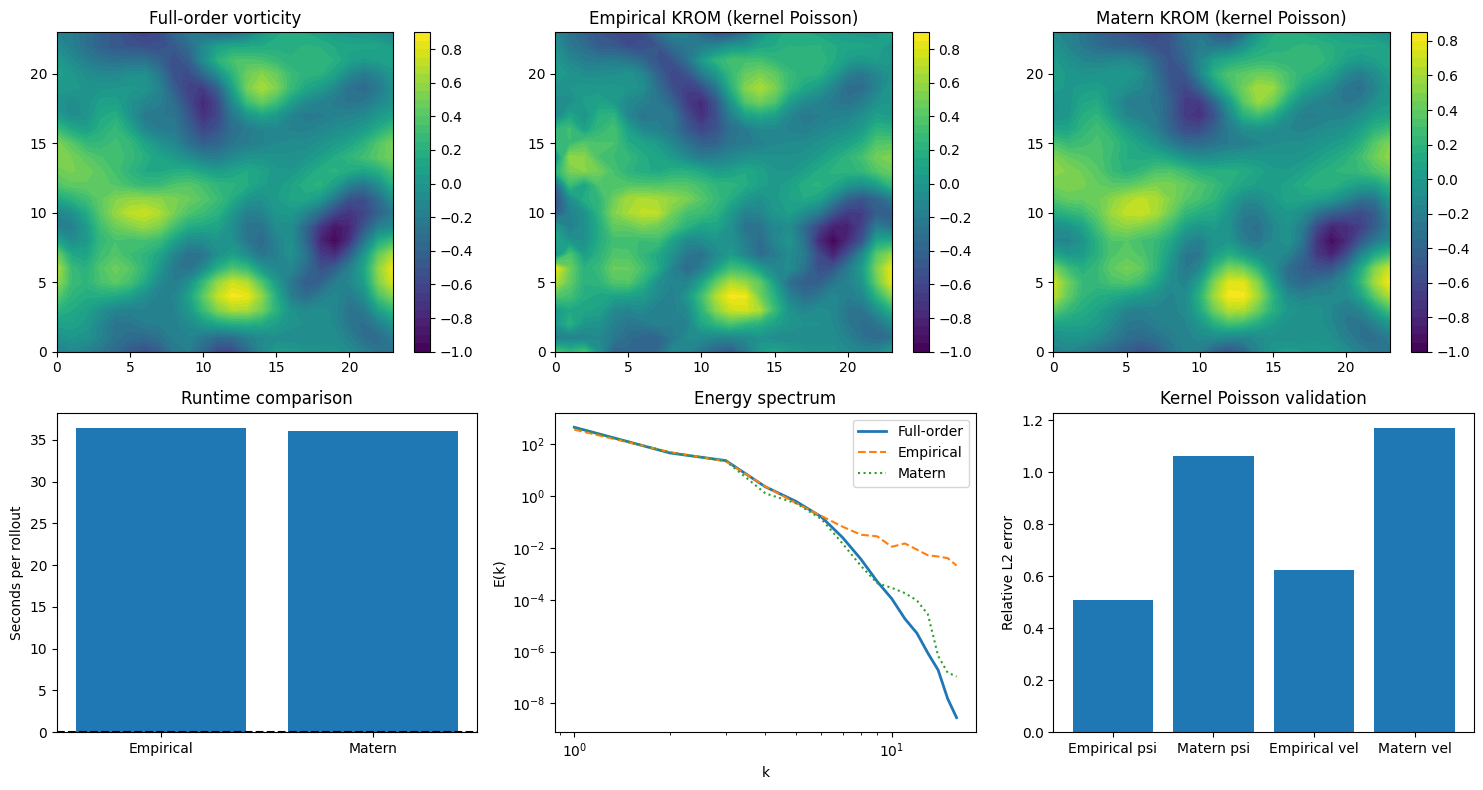

In [3]:
kernel_result = NS_Vorticity_clean.run_experiment(poisson_solver='kernel')
NS_Vorticity_clean.plot_experiment(kernel_result)
kernel_result['empirical'], kernel_result['matern']


In [4]:
fft_rho = NS_Vorticity_clean.run_rho_sweep([2.0, 3.0, 4.0], poisson_solver='fft')
fft_train = NS_Vorticity_clean.run_train_sweep([4, 8, 12], poisson_solver='fft')
NS_Vorticity_clean.plot_sweeps(fft_rho, fft_train)


KeyboardInterrupt: 

In [ ]:
kernel_rho = NS_Vorticity_clean.run_rho_sweep([2.0, 3.0, 4.0], poisson_solver='kernel')
kernel_train = NS_Vorticity_clean.run_train_sweep([4, 8, 12], poisson_solver='kernel')
NS_Vorticity_clean.plot_sweeps(kernel_rho, kernel_train)
